In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
# Import Libraries
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import time

warnings.filterwarnings('ignore')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# Create Output Directories
# ============================================================================

if not os.path.exists('./preprocessed_data'):
    os.makedirs('./preprocessed_data')
    print("✓ Created ./preprocessed_data folder")

if not os.path.exists('./visualizations'):
    os.makedirs('./visualizations')
    print("✓ Created ./visualizations folder")

print()

✓ Created ./preprocessed_data folder
✓ Created ./visualizations folder



In [5]:
# Load All 4 CSV Files
# ============================================================================

print("="*80)
print("STEP 1: LOADING DATA")
print("="*80)
print()

start_time = time.time()

print("Loading train_transaction.csv...")
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
print(f"  Shape: {train_transaction.shape}")

print("Loading test_transaction.csv...")
test_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
print(f"  Shape: {test_transaction.shape}")

print("Loading train_identity.csv...")
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
print(f"  Shape: {train_identity.shape}")

print("Loading test_identity.csv...")
test_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')
print(f"  Shape: {test_identity.shape}")

load_time = time.time() - start_time
print(f"\n✓ Data loaded in {load_time:.2f} seconds\n")

STEP 1: LOADING DATA

Loading train_transaction.csv...
  Shape: (590540, 394)
Loading test_transaction.csv...
  Shape: (506691, 393)
Loading train_identity.csv...
  Shape: (144233, 41)
Loading test_identity.csv...
  Shape: (141907, 41)

✓ Data loaded in 50.95 seconds



In [6]:
# Merge Transaction and Identity Data
# ============================================================================

print("="*80)
print("STEP 2: MERGING DATA")
print("="*80)
print()

print("Merging transaction and identity data...")
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"✓ Train set merged: {train.shape}")
print(f"✓ Test set merged: {test.shape}")
print()

STEP 2: MERGING DATA

Merging transaction and identity data...
✓ Train set merged: (590540, 434)
✓ Test set merged: (506691, 433)



In [7]:
# Display Basic Information
# ============================================================================

print("="*80)
print("STEP 3: BASIC DATA EXPLORATION")
print("="*80)
print()

print("First 5 rows of training data:")
print(train.head())
print()

print("Dataset Info:")
print(train.info())
print()

print("Statistical Summary:")
print(train.describe())
print()

STEP 3: BASIC DATA EXPLORATION

First 5 rows of training data:
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  150.0  mastercard  102.0  ...                  NaN    NaN   
2  490.0  150.0        visa  166.0  ...                  NaN    NaN   
3  567.0  150.0  mastercard  117.0  ...                  NaN    NaN   
4  514.0  150.0  mastercard  102.0  ...  samsung browser 6.2   32.0   

       id_33           id_34  id_35 id_36 id_37

In [8]:
# Check Missing Values
# ============================================================================

print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
print()

missing_train = train.isnull().sum()
missing_pct = (missing_train / len(train)) * 100

missing_df = pd.DataFrame({
    'Column': missing_train.index,
    'Missing_Count': missing_train.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Percentage', ascending=False)

print("Top 15 columns with missing values:")
print(missing_df[missing_df['Missing_Percentage'] > 0].head(15).to_string())
print()

MISSING VALUES ANALYSIS

Top 15 columns with missing values:
    Column  Missing_Count  Missing_Percentage
417  id_24         585793           99.196159
418  id_25         585408           99.130965
400  id_07         585385           99.127070
401  id_08         585385           99.127070
414  id_21         585381           99.126393
419  id_26         585377           99.125715
420  id_27         585371           99.124699
416  id_23         585371           99.124699
415  id_22         585371           99.124699
14   dist2         552913           93.628374
37      D7         551623           93.409930
411  id_18         545427           92.360721
43     D13         528588           89.509263
44     D14         528353           89.469469
42     D12         525823           89.041047



In [9]:
# Fraud Distribution
# ============================================================================

print("="*80)
print("FRAUD DISTRIBUTION ANALYSIS")
print("="*80)
print()

fraud_counts = train['isFraud'].value_counts()
fraud_pct = train['isFraud'].value_counts(normalize=True) * 100

print(f"Legitimate transactions: {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent transactions: {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"Fraud Rate: {fraud_pct[1]:.2f}%")
print()

FRAUD DISTRIBUTION ANALYSIS

Legitimate transactions: 569,877 (96.50%)
Fraudulent transactions: 20,663 (3.50%)
Fraud Rate: 3.50%



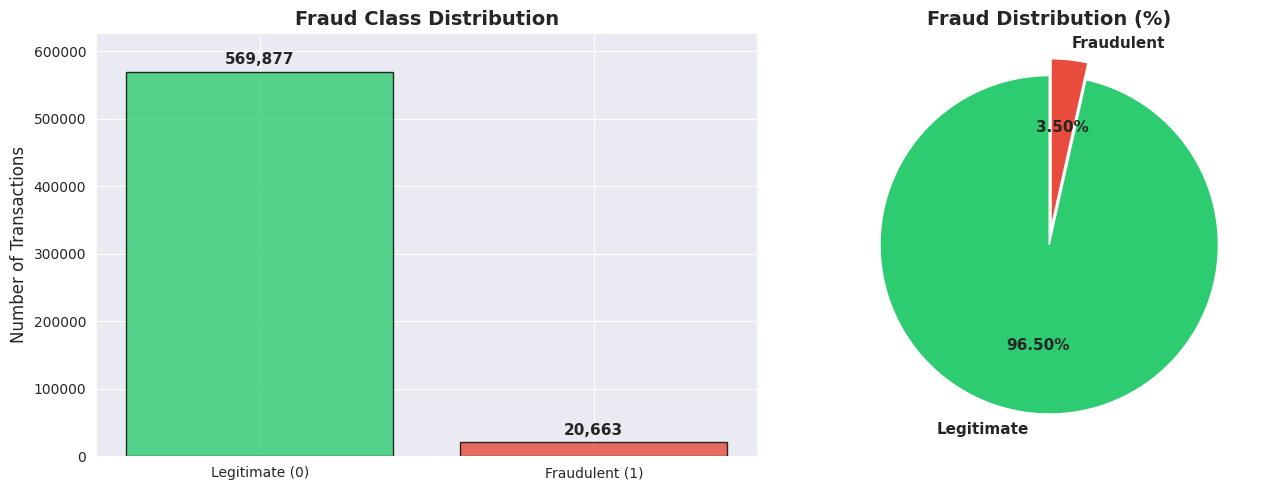

✓ Saved visualization: 01_fraud_distribution.png



In [10]:
# Visualize Fraud Distribution
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], 
           [fraud_counts[0], fraud_counts[1]], 
           color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Fraud Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions', fontsize=12)
axes[0].set_ylim([0, fraud_counts[0] * 1.1])
for i, v in enumerate([fraud_counts[0], fraud_counts[1]]):
    axes[0].text(i, v + fraud_counts[0]*0.02, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[1].pie([fraud_counts[0], fraud_counts[1]], 
           labels=['Legitimate', 'Fraudulent'],
           autopct='%1.2f%%',
           colors=colors,
           explode=explode,
           startangle=90,
           textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Fraud Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./visualizations/01_fraud_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved visualization: 01_fraud_distribution.png\n")

In [11]:
# Separate Features and Target
# ============================================================================

print("="*80)
print("STEP 4: DATA PREPROCESSING")
print("="*80)
print()

X_train = train.drop(['isFraud', 'TransactionID'], axis=1)
y_train = train['isFraud']
X_test = test.drop('TransactionID', axis=1)

print(f"Initial feature count: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")
print()

STEP 4: DATA PREPROCESSING

Initial feature count: 432
Training samples: 590,540
Test samples: 506,691



In [12]:
# Handle Missing Values 
# ============================================================================

print("Handling missing values...")

# Get numeric columns from X_train
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# Fill numeric columns with median - ensure columns exist in both datasets
for col in numeric_cols:
    if col in X_train.columns and col in X_test.columns:
        X_train[col] = X_train[col].fillna(X_train[col].median())
        X_test[col] = X_test[col].fillna(X_train[col].median())

print(f"✓ Filled numeric missing values with median")

# Fill categorical columns with mode
categorical_cols = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col in X_train.columns and col in X_test.columns:
        mode_val = X_train[col].mode()
        if len(mode_val) > 0:
            X_train[col] = X_train[col].fillna(mode_val[0])
            X_test[col] = X_test[col].fillna(mode_val[0])

print(f"✓ Filled categorical missing values with mode")

# Remove columns from X_test that don't exist in X_train
cols_to_remove = set(X_test.columns) - set(X_train.columns)
if cols_to_remove:
    print(f"✓ Removing {len(cols_to_remove)} columns from test that don't exist in train")
    X_test = X_test.drop(cols_to_remove, axis=1)
# Add columns to X_test that exist in X_train but not in X_test (fill with 0)
cols_to_add = set(X_train.columns) - set(X_test.columns)
if cols_to_add:
    print(f"✓ Adding {len(cols_to_add)} missing columns to test set (filled with 0)")
    for col in cols_to_add:
        X_test[col] = 0

# Make sure X_test has same columns as X_train in same order
X_test = X_test[X_train.columns]

print(f"✓ Remaining missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"✓ Remaining missing values in X_test: {X_test.isnull().sum().sum()}")
print()

Handling missing values...
✓ Filled numeric missing values with median
✓ Filled categorical missing values with mode
✓ Removing 38 columns from test that don't exist in train
✓ Adding 38 missing columns to test set (filled with 0)
✓ Remaining missing values in X_train: 19034783
✓ Remaining missing values in X_test: 0



In [13]:
# Drop Sparse Columns
# ============================================================================

print("Dropping sparse columns...")

missing_threshold = 0.8
cols_to_drop = X_train.columns[X_train.isnull().sum() > len(X_train) * missing_threshold]
X_train = X_train.drop(cols_to_drop, axis=1)
X_test = X_test.drop(cols_to_drop, axis=1)

print(f"✓ Dropped {len(cols_to_drop)} columns with >{missing_threshold*100}% missing values")

Dropping sparse columns...
✓ Dropped 19 columns with >80.0% missing values


In [14]:
# Select Only Numeric Columns
# ============================================================================

print("Selecting numeric features only...")

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train = X_train[numeric_cols]
X_test = X_test[numeric_cols]

print(f"✓ Selected {len(numeric_cols)} numeric features")
print(f"✓ Final X_train shape: {X_train.shape}")
print(f"✓ Final X_test shape: {X_test.shape}")
print()

Selecting numeric features only...
✓ Selected 387 numeric features
✓ Final X_train shape: (590540, 387)
✓ Final X_test shape: (506691, 387)



In [15]:
# Feature Scaling
# ============================================================================

print("="*80)
print("STEP 5: FEATURE SCALING")
print("="*80)
print()

print("Scaling features with StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"✓ Features scaled")
print(f"  Train mean: {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"  Train std: {X_train_scaled.std(axis=0).mean():.6f}")
print()

STEP 5: FEATURE SCALING

Scaling features with StandardScaler...
✓ Features scaled
  Train mean: -0.000000
  Train std: 1.000001



In [16]:
# Train-Validation-Test Split
# ============================================================================

print("="*80)
print("STEP 6: TRAIN-VALIDATION SPLIT")
print("="*80)
print()

print("Splitting data into train and validation sets...")
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

print(f"✓ Train set: {X_train_split.shape}")
print(f"✓ Validation set: {X_val_split.shape}")
print(f"✓ Test set: {X_test_scaled.shape}")
print()

print("Class distribution in splits:")
print(f"  Train: {np.bincount(y_train_split.values)}")
print(f"  Validation: {np.bincount(y_val_split.values)}")
print()

STEP 6: TRAIN-VALIDATION SPLIT

Splitting data into train and validation sets...
✓ Train set: (472432, 387)
✓ Validation set: (118108, 387)
✓ Test set: (506691, 387)

Class distribution in splits:
  Train: [455902  16530]
  Validation: [113975   4133]



In [17]:
# =============================================================================
# FIX: HANDLE MISSING VALUES BEFORE SMOTE
# =============================================================================

from sklearn.impute import SimpleImputer
import numpy as np

print("Checking NaNs before SMOTE...")
print("NaNs in X_train_split:", np.isnan(X_train_split).sum())

imputer = SimpleImputer(strategy='median')

X_train_split = imputer.fit_transform(X_train_split)

print("NaNs after fix:", np.isnan(X_train_split).sum())
print("✓ Missing values handled\n")

Checking NaNs before SMOTE...
NaNs in X_train_split: TransactionDT          0
TransactionAmt         0
card1                  0
card2                  0
card3                  0
                   ...  
id_11             359353
id_13             370347
id_17             360631
id_19             360673
id_20             360719
Length: 387, dtype: int64
NaNs after fix: 0
✓ Missing values handled



In [18]:
# Apply SMOTE
# ============================================================================

print("="*80)
print("STEP 7: SMOTE - HANDLING CLASS IMBALANCE")
print("="*80)
print()

print("Applying SMOTE to training data...")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_split, y_train_split)

print(f"✓ SMOTE applied successfully")
print()

STEP 7: SMOTE - HANDLING CLASS IMBALANCE

Applying SMOTE to training data...
✓ SMOTE applied successfully



In [19]:
# SMOTE Analysis
# ============================================================================

print("="*80)
print("SMOTE ANALYSIS")
print("="*80)
print()

print("Before SMOTE:")
before_counts = np.bincount(y_train_split.values)
print(f"  Legitimate: {before_counts[0]:,} ({before_counts[0]/len(y_train_split)*100:.2f}%)")
print(f"  Fraudulent: {before_counts[1]:,} ({before_counts[1]/len(y_train_split)*100:.2f}%)")
print(f"  Imbalance ratio: 1:{before_counts[0]/before_counts[1]:.2f}")
print()

print("After SMOTE:")
after_counts = np.bincount(y_train_smote)
print(f"  Legitimate: {after_counts[0]:,} ({after_counts[0]/len(y_train_smote)*100:.2f}%)")
print(f"  Fraudulent: {after_counts[1]:,} ({after_counts[1]/len(y_train_smote)*100:.2f}%)")
print(f"  Imbalance ratio: 1:{after_counts[0]/after_counts[1]:.2f}")
print()

SMOTE ANALYSIS

Before SMOTE:
  Legitimate: 455,902 (96.50%)
  Fraudulent: 16,530 (3.50%)
  Imbalance ratio: 1:27.58

After SMOTE:
  Legitimate: 455,902 (50.00%)
  Fraudulent: 455,902 (50.00%)
  Imbalance ratio: 1:1.00



In [20]:
X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=[f"feature_{i}" for i in range(X_train_smote.shape[1])]
)

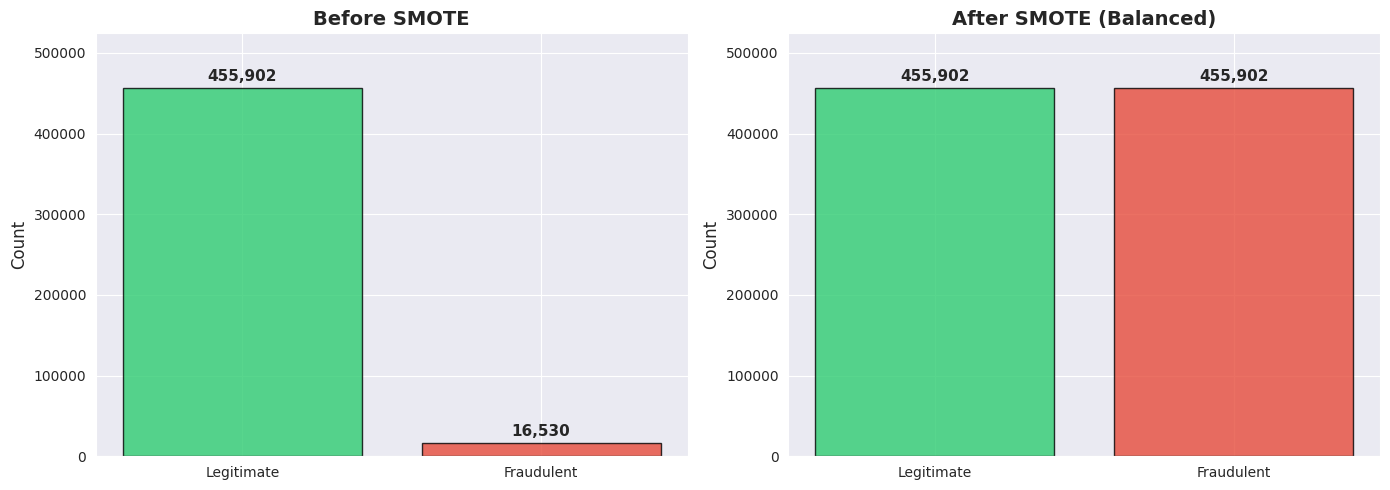

✓ Saved visualization: 02_smote_comparison.png



In [21]:
# Visualize SMOTE Effect
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
before_data = pd.Series(y_train_split.values)
before_counts_viz = before_data.value_counts()
axes[0].bar(['Legitimate', 'Fraudulent'], 
           [before_counts_viz[0], before_counts_viz[1]], 
           color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim([0, max(before_counts_viz) * 1.15])
for i, v in enumerate([before_counts_viz[0], before_counts_viz[1]]):
    axes[0].text(i, v + max(before_counts_viz)*0.02, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# After SMOTE
after_data = pd.Series(y_train_smote)
after_counts_viz = after_data.value_counts()
axes[1].bar(['Legitimate', 'Fraudulent'], 
           [after_counts_viz[0], after_counts_viz[1]], 
           color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_ylim([0, max(after_counts_viz) * 1.15])
for i, v in enumerate([after_counts_viz[0], after_counts_viz[1]]):
    axes[1].text(i, v + max(after_counts_viz)*0.02, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualizations/02_smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved visualization: 02_smote_comparison.png\n")

In [22]:
# SMOTE Statistics
# ============================================================================

print("SMOTE Statistics:")
print(f"  Original samples: {len(y_train_split):,}")
print(f"  Synthetic samples added: {len(y_train_smote) - len(y_train_split):,}")
print(f"  Total after SMOTE: {len(y_train_smote):,}")
print(f"  Increase: {(len(y_train_smote) / len(y_train_split) - 1) * 100:.1f}%")
print()

SMOTE Statistics:
  Original samples: 472,432
  Synthetic samples added: 439,372
  Total after SMOTE: 911,804
  Increase: 93.0%



In [23]:
# Feature Statistics
# ============================================================================

print("="*80)
print("STEP 8: FEATURE ANALYSIS")
print("="*80)
print()

print("Feature statistics (on scaled training data):")
print(f"  Number of features: {X_train_smote.shape[1]}")
print(f"  Feature names: {list(X_train_smote.columns[:10])}...")
print()

feature_stats = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Mean': X_train_smote.mean(),
    'Std': X_train_smote.std(),
    'Min': X_train_smote.min(),
    'Max': X_train_smote.max()
}).round(4)

print("Top 10 features by standard deviation:")
print(feature_stats.nlargest(10, 'Std')[['Feature', 'Mean', 'Std']].to_string(index=False))
print()

STEP 8: FEATURE ANALYSIS

Feature statistics (on scaled training data):
  Number of features: 387
  Feature names: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']...

Top 10 features by standard deviation:
    Feature   Mean    Std
feature_238 0.5920 3.5187
feature_239 0.6071 3.4617
 feature_82 0.5412 3.4392
feature_295 0.6853 3.4148
feature_284 0.6502 3.3430
 feature_83 0.5749 3.2888
feature_226 0.5301 3.1327
feature_282 0.6385 3.1054
feature_280 0.6335 3.0695
feature_227 0.5395 3.0355



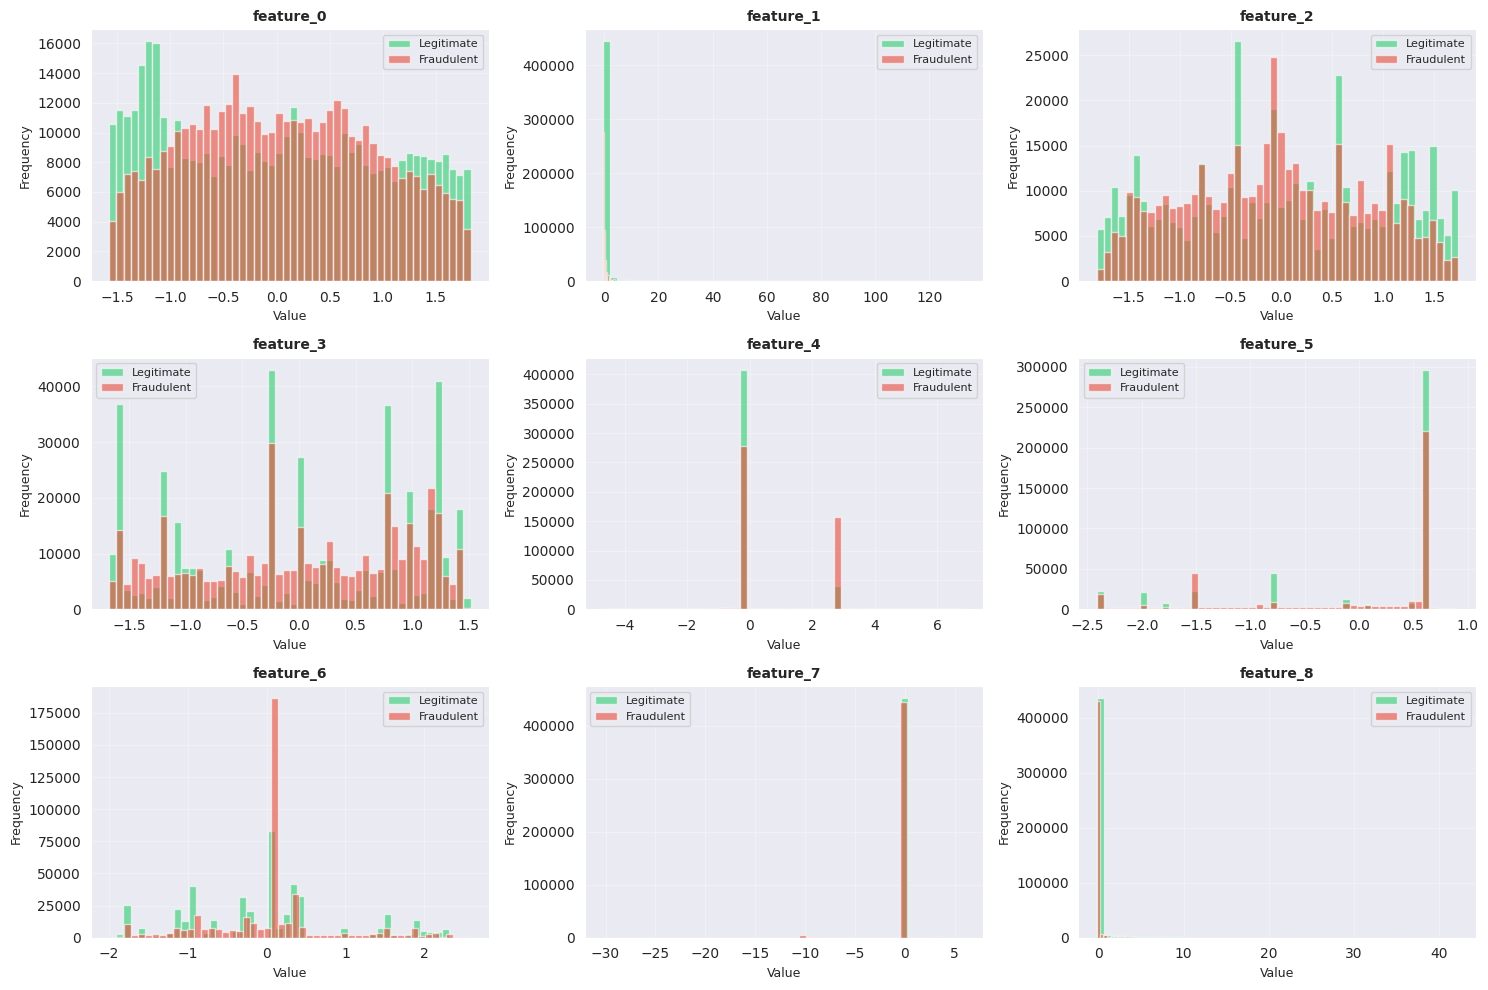

✓ Saved visualization: 03_feature_distributions.png



In [24]:
# Visualize Feature Distributions
# ============================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(min(9, X_train_smote.shape[1])):
    feature = X_train_smote.columns[i]
    
    # Legitimate transactions
    axes[i].hist(X_train_smote[y_train_smote == 0][feature], 
                bins=50, alpha=0.6, label='Legitimate', color='#2ecc71')
    # Fraudulent transactions
    axes[i].hist(X_train_smote[y_train_smote == 1][feature], 
                bins=50, alpha=0.6, label='Fraudulent', color='#e74c3c')
    
    axes[i].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./visualizations/03_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved visualization: 03_feature_distributions.png\n")

In [25]:
# Save Preprocessed Data
# ============================================================================

print("="*80)
print("STEP 9: SAVING PREPROCESSED DATA")
print("="*80)
print()

print("Saving preprocessed data...")

# Save training data (before SMOTE)
with open('./preprocessed_data/X_train_processed.pkl', 'wb') as f:
    pickle.dump(X_train_split, f)
print("✓ Saved: X_train_processed.pkl")

with open('./preprocessed_data/y_train.pkl', 'wb') as f:
    pickle.dump(y_train_split, f)
print("✓ Saved: y_train.pkl")

# Save validation data
with open('./preprocessed_data/X_val_processed.pkl', 'wb') as f:
    pickle.dump(X_val_split, f)
print("✓ Saved: X_val_processed.pkl")

with open('./preprocessed_data/y_val.pkl', 'wb') as f:
    pickle.dump(y_val_split, f)
print("✓ Saved: y_val.pkl")
# Save test data
with open('./preprocessed_data/X_test_processed.pkl', 'wb') as f:
    pickle.dump(X_test_scaled, f)
print("✓ Saved: X_test_processed.pkl")

# Save SMOTE data
with open('./preprocessed_data/X_train_smote.pkl', 'wb') as f:
    pickle.dump(X_train_smote, f)
print("✓ Saved: X_train_smote.pkl")

with open('./preprocessed_data/y_train_smote.pkl', 'wb') as f:
    pickle.dump(y_train_smote, f)
print("✓ Saved: y_train_smote.pkl")

# Save scaler
with open('./preprocessed_data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Saved: scaler.pkl")

# Save feature columns
with open('./preprocessed_data/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train_smote.columns), f)
print("✓ Saved: feature_columns.pkl")

print()
print("All preprocessed data saved successfully!")

STEP 9: SAVING PREPROCESSED DATA

Saving preprocessed data...
✓ Saved: X_train_processed.pkl
✓ Saved: y_train.pkl
✓ Saved: X_val_processed.pkl
✓ Saved: y_val.pkl
✓ Saved: X_test_processed.pkl
✓ Saved: X_train_smote.pkl
✓ Saved: y_train_smote.pkl
✓ Saved: scaler.pkl
✓ Saved: feature_columns.pkl

All preprocessed data saved successfully!


In [26]:
# Save Metadata
# ============================================================================

print("="*80)
print("SAVING METADATA")
print("="*80)
print()

metadata = {
    'dataset_name': 'IEEE-CIS Fraud Detection',
    'preprocessing_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'original_train_samples': len(train),
    'original_test_samples': len(test),
    'original_features': X_train.shape[1],
    'final_features': X_train_smote.shape[1],
    'feature_names': list(X_train_smote.columns),
    'train_split_samples': len(X_train_split),
    'val_split_samples': len(X_val_split),
    'test_samples': len(X_test_scaled),
    'before_smote': {
        'legitimate': int(before_counts[0]),
        'fraudulent': int(before_counts[1]),
        'imbalance_ratio': f"1:{before_counts[0]/before_counts[1]:.2f}"
    },
    'after_smote': {
        'legitimate': int(after_counts[0]),
        'fraudulent': int(after_counts[1]),
        'imbalance_ratio': f"1:{after_counts[0]/after_counts[1]:.2f}"
    },
    'scaler_type': 'StandardScaler',
    'files_generated': [
        'X_train_processed.pkl',
        'y_train.pkl',
        'X_val_processed.pkl',
        'y_val.pkl',
        'X_test_processed.pkl',
        'X_train_smote.pkl',
        'y_train_smote.pkl',
        'scaler.pkl',
        'feature_columns.pkl',
        'metadata.txt'
    ]
}
# Save as text file
with open('./preprocessed_data/metadata.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("PREPROCESSING METADATA\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Dataset: {metadata['dataset_name']}\n")
    f.write(f"Preprocessing Date: {metadata['preprocessing_date']}\n\n")
    
    f.write("ORIGINAL DATA:\n")
    f.write(f"  Train samples: {metadata['original_train_samples']:,}\n")
    f.write(f"  Test samples: {metadata['original_test_samples']:,}\n")
    f.write(f"  Original features: {metadata['original_features']}\n\n")
    
    f.write("AFTER PREPROCESSING:\n")
    f.write(f"  Final features: {metadata['final_features']}\n")
    f.write(f"  Train split samples: {metadata['train_split_samples']:,}\n")
    f.write(f"  Validation split samples: {metadata['val_split_samples']:,}\n")
    f.write(f"  Test samples: {metadata['test_samples']:,}\n\n")
    
    f.write("BEFORE SMOTE:\n")
    f.write(f"  Legitimate: {metadata['before_smote']['legitimate']:,}\n")
    f.write(f"  Fraudulent: {metadata['before_smote']['fraudulent']:,}\n")
    f.write(f"  Imbalance Ratio: {metadata['before_smote']['imbalance_ratio']}\n\n")
    f.write("AFTER SMOTE:\n")
    f.write(f"  Legitimate: {metadata['after_smote']['legitimate']:,}\n")
    f.write(f"  Fraudulent: {metadata['after_smote']['fraudulent']:,}\n")
    f.write(f"  Imbalance Ratio: {metadata['after_smote']['imbalance_ratio']}\n\n")
    
    f.write("FILES GENERATED:\n")
    for file in metadata['files_generated']:
        f.write(f"  - {file}\n")

print("✓ Saved: metadata.txt")
print()

SAVING METADATA

✓ Saved: metadata.txt



In [27]:
# Summary Report
# ============================================================================

print("="*80)
print("PREPROCESSING SUMMARY REPORT")
print("="*80)
print()

print("📊 DATASET STATISTICS:")
print(f"  Original train: {metadata['original_train_samples']:,} samples")
print(f"  Original test: {metadata['original_test_samples']:,} samples")
print(f"  Original features: {metadata['original_features']}")
print()

print("📈 AFTER PROCESSING:")
print(f"  Final features: {metadata['final_features']}")
print(f"  Train samples: {metadata['train_split_samples']:,}")
print(f"  Validation samples: {metadata['val_split_samples']:,}")
print(f"  Test samples: {metadata['test_samples']:,}")
print()

print("⚖️  CLASS BALANCE:")
print(f"  Before SMOTE: {metadata['before_smote']['imbalance_ratio']}")
print(f"  After SMOTE: {metadata['after_smote']['imbalance_ratio']}")
print(f"  Synthetic samples added: {len(y_train_smote) - len(y_train_split):,}")
print()

print("💾 FILES SAVED:")
for file in metadata['files_generated']:
    print(f"  ✓ {file}")
print()

print("="*80)
print("✅ PREPROCESSING COMPLETE!")
print("="*80)
print()

print("📝 NEXT STEPS FOR TEAM MEMBERS:")
print("  1. Each team member should pull the latest code from GitHub")
print("  2. Load preprocessed data using pickle.load() in your notebook")
print("  3. Use X_train_smote and y_train_smote for model training")
print("  4. Use X_val_processed and y_val for validation")
print("  5. Use X_test_processed for final testing")
print()

PREPROCESSING SUMMARY REPORT

📊 DATASET STATISTICS:
  Original train: 590,540 samples
  Original test: 506,691 samples
  Original features: 387

📈 AFTER PROCESSING:
  Final features: 387
  Train samples: 472,432
  Validation samples: 118,108
  Test samples: 506,691

⚖️  CLASS BALANCE:
  Before SMOTE: 1:27.58
  After SMOTE: 1:1.00
  Synthetic samples added: 439,372

💾 FILES SAVED:
  ✓ X_train_processed.pkl
  ✓ y_train.pkl
  ✓ X_val_processed.pkl
  ✓ y_val.pkl
  ✓ X_test_processed.pkl
  ✓ X_train_smote.pkl
  ✓ y_train_smote.pkl
  ✓ scaler.pkl
  ✓ feature_columns.pkl
  ✓ metadata.txt

✅ PREPROCESSING COMPLETE!

📝 NEXT STEPS FOR TEAM MEMBERS:
  1. Each team member should pull the latest code from GitHub
  2. Load preprocessed data using pickle.load() in your notebook
  3. Use X_train_smote and y_train_smote for model training
  4. Use X_val_processed and y_val for validation
  5. Use X_test_processed for final testing



In [28]:
# Display Preprocessed Data Info
# ============================================================================

print("="*80)
print("PREPROCESSED DATA INFORMATION")
print("="*80)
print()

print("X_train_smote (for training):")
print(f"  Shape: {X_train_smote.shape}")
print(f"  Data type: {type(X_train_smote)}")
print(f"  Memory usage: {X_train_smote.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"  Sample row:\n{X_train_smote.iloc[0].head()}")
print()

print("y_train_smote (target):")
print(f"  Shape: {y_train_smote.shape}")
print(f"  Data type: {type(y_train_smote)}")
print(f"  Unique values: {np.unique(y_train_smote)}")
print(f"  Distribution: {np.bincount(y_train_smote)}")
print()

print("X_val_processed (for validation):")
print(f"  Shape: {X_val_split.shape}")
print(f"  Data type: {type(X_val_split)}")
print()

print("X_test_processed (for testing):")
print(f"  Shape: {X_test_scaled.shape}")
print(f"  Data type: {type(X_test_scaled)}")
print()


PREPROCESSED DATA INFORMATION

X_train_smote (for training):
  Shape: (911804, 387)
  Data type: <class 'pandas.core.frame.DataFrame'>
  Memory usage: 2822.95 MB
  Sample row:
feature_0   -1.378280
feature_1   -0.146458
feature_2   -0.759357
feature_3    0.232881
feature_4   -0.281425
Name: 0, dtype: float64

y_train_smote (target):
  Shape: (911804,)
  Data type: <class 'pandas.core.series.Series'>
  Unique values: [0 1]
  Distribution: [455902 455902]

X_val_processed (for validation):
  Shape: (118108, 387)
  Data type: <class 'pandas.core.frame.DataFrame'>

X_test_processed (for testing):
  Shape: (506691, 387)
  Data type: <class 'pandas.core.frame.DataFrame'>



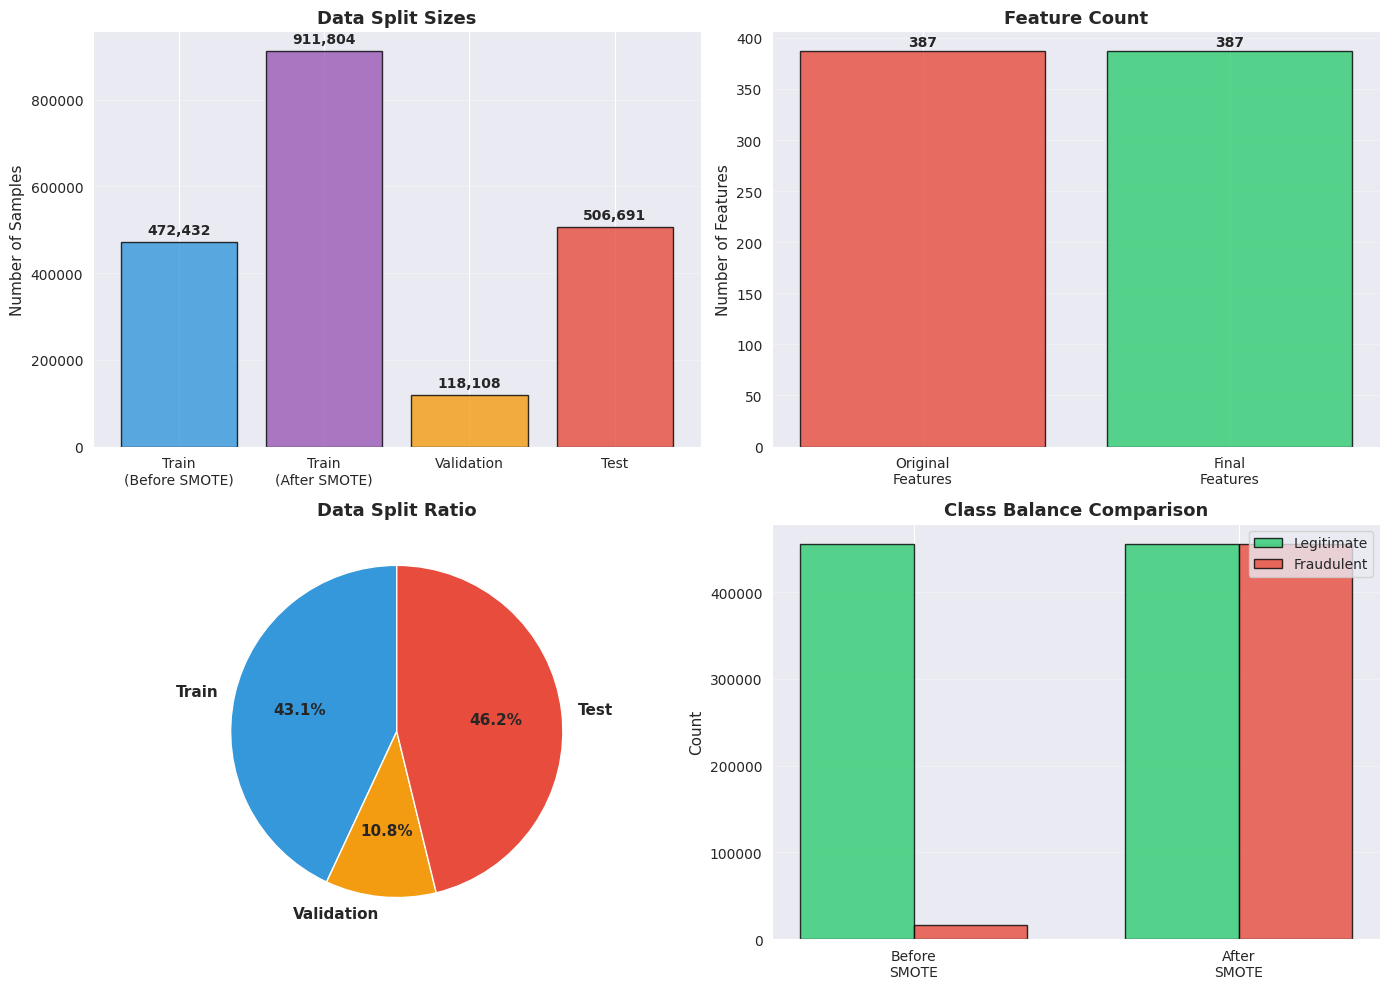

✓ Saved visualization: 04_preprocessing_overview.png

✅ ALL PREPROCESSING COMPLETE AND DATA SAVED!


In [29]:
# Visualization Overview
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Data split sizes
split_names = ['Train\n(Before SMOTE)', 'Train\n(After SMOTE)', 'Validation', 'Test']
split_sizes = [len(X_train_split), len(X_train_smote), len(X_val_split), len(X_test_scaled)]
colors_split = ['#3498db', '#9b59b6', '#f39c12', '#e74c3c']

axes[0, 0].bar(split_names, split_sizes, color=colors_split, alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Data Split Sizes', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Number of Samples', fontsize=11)
for i, v in enumerate(split_sizes):
    axes[0, 0].text(i, v + max(split_sizes)*0.02, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Feature count
axes[0, 1].bar(['Original\nFeatures', 'Final\nFeatures'], 
              [metadata['original_features'], metadata['final_features']], 
              color=['#e74c3c', '#2ecc71'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Feature Count', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Number of Features', fontsize=11)
for i, v in enumerate([metadata['original_features'], metadata['final_features']]):
    axes[0, 1].text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
# Plot 3: Train-Val-Test ratio
axes[1, 0].pie([len(X_train_split), len(X_val_split), len(X_test_scaled)],
              labels=['Train', 'Validation', 'Test'],
              autopct='%1.1f%%',
              colors=['#3498db', '#f39c12', '#e74c3c'],
              startangle=90,
              textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1, 0].set_title('Data Split Ratio', fontsize=13, fontweight='bold')

# Plot 4: Class balance comparison
categories = ['Before\nSMOTE', 'After\nSMOTE']
legitimate = [before_counts[0], after_counts[0]]
fraudulent = [before_counts[1], after_counts[1]]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, legitimate, width, label='Legitimate', color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width/2, fraudulent, width, label='Fraudulent', color='#e74c3c', alpha=0.8, edgecolor='black')

axes[1, 1].set_title('Class Balance Comparison', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./visualizations/04_preprocessing_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved visualization: 04_preprocessing_overview.png\n")

print("="*80)
print("✅ ALL PREPROCESSING COMPLETE AND DATA SAVED!")
print("="*80)


In [34]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, f1_score, precision_score, recall_score
)
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")

In [35]:
with open('./preprocessed_data/X_train_smote.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('./preprocessed_data/y_train_smote.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('./preprocessed_data/X_val_processed.pkl', 'rb') as f:
    X_val = pickle.load(f)
with open('./preprocessed_data/y_val.pkl', 'rb') as f:
    y_val = pickle.load(f)
with open('./preprocessed_data/X_test_processed.pkl', 'rb') as f:
    X_test = pickle.load(f)

print("Data loaded successfully")

Data loaded successfully


In [70]:
def focal_loss(gamma=2., alpha=0.85):   # ↑ increased alpha for fraud focus
    def focal_crossentropy(y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        y_true = tf.cast(y_true, y_pred.dtype)

        ce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        fl = alpha_t * tf.pow(1 - p_t, gamma) * ce

        return tf.reduce_mean(fl)
    return focal_crossentropy

In [71]:
input_dim = X_train.shape[1]

nn_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(1, activation='sigmoid')
])

In [73]:
nn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0   # prevents NaN
    ),
    loss=focal_loss(alpha=0.85),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [74]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=15,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    )
]

history = nn_model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.6291 - auc: 0.8127 - loss: 0.0494 - precision: 0.5809 - recall: 0.9372 - val_accuracy: 0.8438 - val_auc: 0.0869 - val_loss: nan - val_precision: 0.1108 - val_recall: 0.4926 - learning_rate: 5.0000e-04
Epoch 2/60
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.7165 - auc: 0.9039 - loss: 0.0336 - precision: 0.6438 - recall: 0.9695 - val_accuracy: 0.8663 - val_auc: 0.0871 - val_loss: nan - val_precision: 0.1278 - val_recall: 0.4842 - learning_rate: 5.0000e-04
Epoch 3/60
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.7537 - auc: 0.9242 - loss: 0.0300 - precision: 0.6765 - recall: 0.9736 - val_accuracy: 0.8763 - val_auc: 0.0876 - val_loss: nan - val_precision: 0.1381 - val_recall: 0.4837 - learning_rate: 5.0000e-04
Epoch 4/60
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.7712 - auc: 0.9332 - loss: 0.0282 - precision: 0.6925 - recall: 0.9751 - val_accuracy: 0.8834 - val_auc: 0.0878 - val_los

In [75]:
y_val_proba = nn_model.predict(X_val).flatten()

# Remove NaNs just in case
y_val_proba = np.nan_to_num(y_val_proba)

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [77]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.6, 0.02)

best_f1 = 0
best_threshold = 0

print("Threshold | Precision | Recall | F1")
print("-"*40)

for t in thresholds:
    y_pred = (y_val_proba > t).astype(int)

    p = precision_score(y_val, y_pred, zero_division=0)
    r = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(f"{t:.2f}      | {p:.3f}     | {r:.3f}  | {f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best F1:", best_f1)

Threshold | Precision | Recall | F1
----------------------------------------
0.10      | 0.095     | 0.495  | 0.160
0.12      | 0.097     | 0.495  | 0.163
0.14      | 0.100     | 0.494  | 0.166
0.16      | 0.102     | 0.494  | 0.169
0.18      | 0.104     | 0.493  | 0.172
0.20      | 0.107     | 0.493  | 0.175
0.22      | 0.109     | 0.492  | 0.179
0.24      | 0.112     | 0.492  | 0.182
0.26      | 0.115     | 0.491  | 0.186
0.28      | 0.117     | 0.489  | 0.189
0.30      | 0.120     | 0.489  | 0.193
0.32      | 0.124     | 0.488  | 0.197
0.34      | 0.127     | 0.486  | 0.202
0.36      | 0.131     | 0.484  | 0.207
0.38      | 0.136     | 0.483  | 0.213
0.40      | 0.141     | 0.482  | 0.219
0.42      | 0.147     | 0.480  | 0.226
0.44      | 0.155     | 0.478  | 0.234
0.46      | 0.163     | 0.475  | 0.242
0.48      | 0.172     | 0.472  | 0.252
0.50      | 0.183     | 0.470  | 0.263
0.52      | 0.195     | 0.465  | 0.275
0.54      | 0.211     | 0.459  | 0.289
0.56      | 0.229     | 0.

In [79]:
y_val_pred = (y_val_proba > best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_val, y_val_pred))

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    113975
           1       0.25      0.45      0.32      4133

    accuracy                           0.93    118108
   macro avg       0.62      0.70      0.64    118108
weighted avg       0.95      0.93      0.94    118108

Precision: 0.2510875475802066
Recall: 0.4468908782966368
F1: 0.3215249368961616
ROC-AUC: 0.6936433226710028


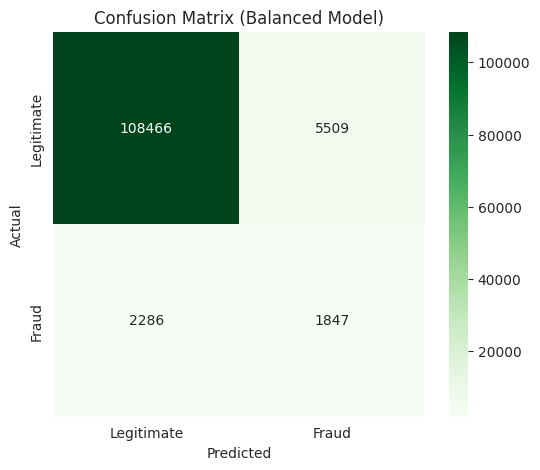

True Negatives: 108466
False Positives: 5509
False Negatives: 2286
True Positives: 1847


In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Apply balanced threshold
y_val_pred = (y_val_proba > best_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title("Confusion Matrix (Balanced Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

In [81]:
# Define business costs
false_negative_cost = 100   # Missing fraud is expensive
false_positive_cost = 1     # False alarm is cheap

# Total cost
total_cost = (fn * false_negative_cost) + (fp * false_positive_cost)

print("\nCost Analysis:")
print("False Negatives:", fn, "→ Cost:", fn * false_negative_cost)
print("False Positives:", fp, "→ Cost:", fp * false_positive_cost)
print("Total Cost:", total_cost)


Cost Analysis:
False Negatives: 2286 → Cost: 228600
False Positives: 5509 → Cost: 5509
Total Cost: 234109


In [84]:
import json
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Metrics
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
accuracy = (y_val_pred == y_val).mean()
roc_auc = roc_auc_score(y_val, y_val_proba)

# Save model
nn_model.save('/kaggle/working/preprocessed_data/neural_network_model.keras')

# Save model info
model_info = {
    'model_name': 'Neural Network (Balanced)',
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'roc_auc': float(roc_auc),
    'threshold': float(best_threshold),
    'confusion_matrix': {
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp)
    },
    'cost_analysis': {
        'false_negative_cost': false_negative_cost,
        'false_positive_cost': false_positive_cost,
        'total_cost': float(total_cost)
    }
}

with open('/kaggle/working/preprocessed_data/nn_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print("\nModel saved successfully!")


Model saved successfully!
